# Machine Learning Pipeline to Analyze and Predict EV Range Anxiety

## Introduction

This notebook presents a machine learning pipeline to analyze and predict EV adoption using user demographics, daily commute distance, and range anxiety level. The objective is to identify key predictive features, evaluate behavioral patterns, and understand how range anxiety and commute needs influence the likelihood of EV adoption. Insights from this analysis can inform manufacturing and infrastructure strategies.

**Research Question:**  
How do range anxiety level and daily commute distance influence the likelihood of EV adoption?

- **Coverage:** Distribution of EV users across demographic groups, commute distances, and range anxiety levels.
- **Density:** Concentration of range anxiety occurrences normalized across driving distances or geographic regions.
- **Accessibility:** Ratios comparing perceived range anxiety to daily user travel requirements and charging access.
- **Composition Mix:** Breakdown of user demographic profiles and charging options.
- **Metric Alignment:** Correlation between range anxiety, commute distance, charging availability, and reported adoption rates.


---

## Python Libraries

This machine learning workflow uses standard Python data science and modeling libraries:
- `pandas` - for data loading, manipulation, and tabular dataset handling
- `numpy` - for vector operations and numerical calculations
- `scipy` - for reading and parsing dataset files in ARFF format
- `scikit-learn` - for missing value imputation, feature encoding and scaling, dimensionality reduction (PCA), machine learning pipelines, model training (Logistic Regression, Random Forests), hyperparameter tuning, and evaluation metrics

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE

from sklearnex import patch_sklearn, config_context
patch_sklearn()
from src import data_utils, feature_handling

%matplotlib inline


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## Data Loading & Initial Inspection

1. **Dataset Ingestion**:
   - Load raw dataset into a Pandas DataFrame to establish the core data structure.

2. **Preliminary Inspection**:
   - Check DataFrame dimensions (`shape`), column names, and infer data types (`info()`).
   - Preview initial records (`head()`) to verify schema integrity and proper parsing before starting ETL.

In [2]:
# Load data
df = pd.read_csv('data/ev_adoption.csv')
df.head()
print(f"Number of rows: {df.shape[0]}")
print(df.dtypes)
print(f"Unique entities: {df[df.columns[0]].nunique()}")

Number of rows: 10000
Buyer_ID                           str
Age                              int64
Gender                             str
Annual_Income_USD              float64
City_Type                          str
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Current_Car_Type                   str
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Home_Charging_Possible             str
Environmental_Concern_Level    float64
Subsidy_Available                  str
Range_Anxiety_Level                str
Will_Buy_EV                        str
dtype: object
Unique entities: 10000


## Exploratory Data Analysis (EDA) & Data Processing

1. **Schema Standardization & Deduplication**:
   - Convert column names to lowercase and strip whitespace for naming consistency.
   - Remove duplicate rows to ensure data integrity.

2. **Missing Value Treatment**:
   - Inspect missing value counts across all features.
   - Clean missing data using context-appropriate imputation (mean for numerical, mode for categorical).

3. **Outlier Filtering**:
   - Target key numerical columns (`age`, `annual_income_usd`, `daily_commute_km`, `environmental_concern_level`).
   - Calculate Z-scores and remove rows exceeding the $Z = 2.5$ threshold to reduce variance and distribution skew.

4. **Validation & Visual Inspection**:
   - Generate summary statistics (`describe()`) and compute post-filtering maximum Z-scores to verify outlier suppression.
   - Plot feature distribution histograms to assess data normality and spread prior to downstream modeling.

--- Step 1: Standardizing columns & removing duplicates ---

--- Step 2: Inspecting missing values ---
Missing values per column:
buyer_id                         0
age                              0
gender                           0
annual_income_usd              178
city_type                        0
daily_commute_km               181
number_of_cars_owned             0
current_car_type                 0
charging_stations_near_home      0
charging_stations_near_work      0
home_charging_possible           0
environmental_concern_level    184
subsidy_available                0
range_anxiety_level              0
will_buy_ev                      0
dtype: int64


--- Step 3: Removing outliers (Z-score threshold = 2.5) ---
Row count: 10000 -> 9936 (Removed 64)

--- Step 4: Inspection & verification ---
DataFrame summary statistics:
               age  annual_income_usd  daily_commute_km  number_of_cars_owned  \
count  9936.000000        9759.000000       9755.000000           9936.000000 

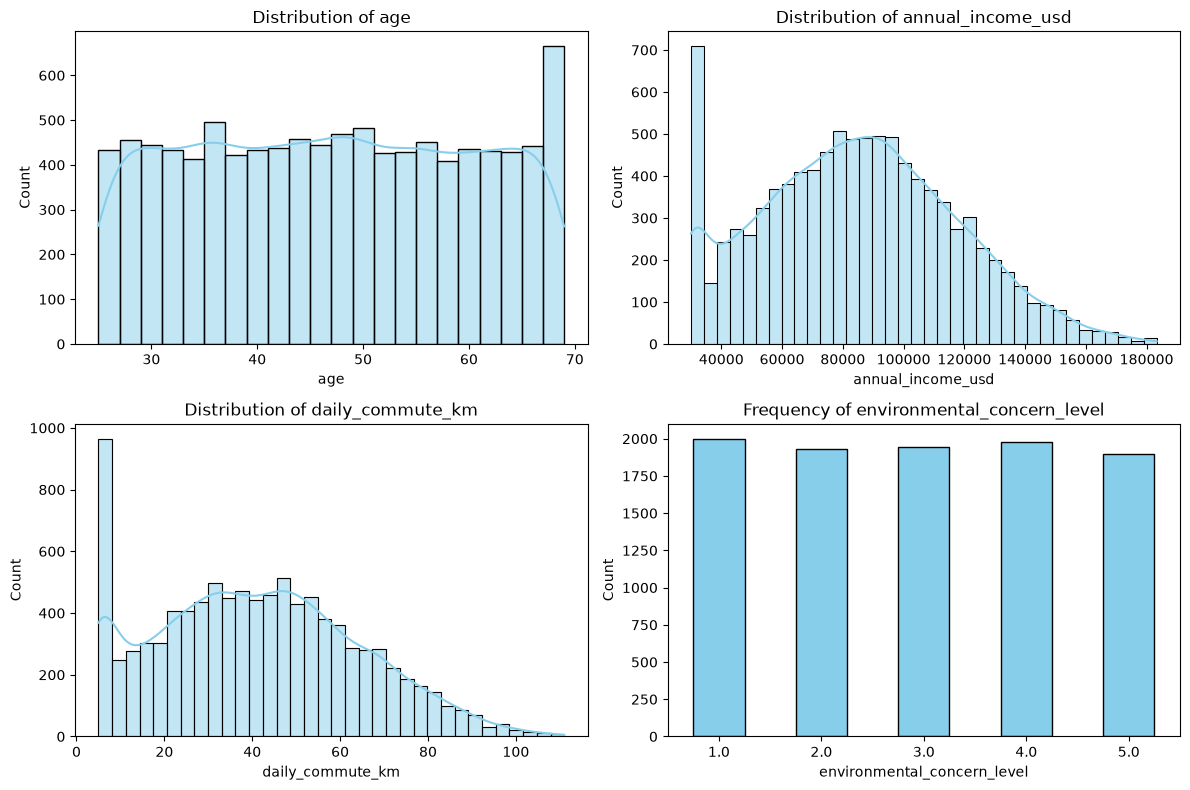

In [3]:
# ==========================================
# 1. SCHEMA STANDARDIZATION & DEDUPLICATION
# ==========================================
print("--- Step 1: Standardizing columns & removing duplicates ---")
df.columns = df.columns.str.strip().str.lower()
df = df.drop_duplicates()

# ==========================================
# 2. MISSING VALUE INSPECTION (NO IMPUTATION)
# ==========================================
print("\n--- Step 2: Inspecting missing values ---")
print(f"Missing values per column:\n{df.isna().sum()}\n")

# ==========================================
# 3. OUTLIER FILTERING (OPTIONAL)
# ==========================================
print("\n--- Step 3: Removing outliers (Z-score threshold = 2.5) ---")
plot_cols = [
    "age",
    "annual_income_usd",
    "daily_commute_km",
    "environmental_concern_level",
]

initial_rows = len(df)
df = data_utils.remove_outliers_by_zscore(df, plot_cols)
final_rows = len(df)

print(
    f"Row count: {initial_rows} -> {final_rows} (Removed"
    f" {initial_rows - final_rows})"
)

# ==========================================
# 4. VALIDATION & VISUALIZATION
# ==========================================
print("\n--- Step 4: Inspection & verification ---")
print("DataFrame summary statistics:")
print(df.describe())

z_scores = (df[plot_cols] - df[plot_cols].mean()).abs() / df[plot_cols].std(ddof=0)
print("\nMax Z-scores after filtering:")
print(z_scores.max())

print("\nPlotting feature distributions")
data_utils.plot_distributions(df, cols=plot_cols)


## Feature Selection

1. **Target Definition**:
   - Set `will_buy_ev` as the target variable to evaluate EV adoption behavior.

2. **Predictor Subset Selection**:
   - **Demographics & Economics**: Retain `age`, `annual_income_usd`, and `city_type`.
   - **Behavioral & Psychological Drivers**: Focus on `daily_commute_km` and `range_anxiety_level` to detect adoption tipping points.
   - **Infrastructure & Financial Incentives**: Include `charging_stations_near_home`, `charging_stations_near_work`, `home_charging_possible`, and `subsidy_available`.

3. **Dimensionality & Noise Reduction**:
   - Drop non-essential attributes to minimize feature noise and focus model evaluation on high-impact variables.

In [15]:
# 1. Include target variable alongside selected predictors (do NOT include daily_commute_km here)
selected_columns = [
    'age',
    'annual_income_usd',
    'city_type',
    'charging_stations_near_home',
    'charging_stations_near_work',
    'home_charging_possible',
    'daily_commute_km',
    'range_anxiety_level',
    'environmental_concern_level',
    'will_buy_ev'  # Target variable
]

# 2. Subset the DataFrame explicitly
df_selected = df[selected_columns].copy()


# 5. Inspect data types and structure
print(df_selected.info())
print(df_selected.nunique())


<class 'pandas.DataFrame'>
RangeIndex: 9936 entries, 0 to 9935
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          9936 non-null   int64  
 1   annual_income_usd            9759 non-null   float64
 2   city_type                    9936 non-null   str    
 3   charging_stations_near_home  9936 non-null   int64  
 4   charging_stations_near_work  9936 non-null   int64  
 5   home_charging_possible       9936 non-null   str    
 6   daily_commute_km             9755 non-null   float64
 7   range_anxiety_level          9936 non-null   str    
 8   environmental_concern_level  9752 non-null   float64
 9   will_buy_ev                  9936 non-null   str    
dtypes: float64(3), int64(3), str(4)
memory usage: 776.4 KB
None
age                              45
annual_income_usd              8855
city_type                         3
charging_stations_near_home      15

## Machine Learning Pipeline



In [5]:
# 3. Train/Test Split
# - x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=..., random_state=...)

# 4. Preprocessing & Feature Engineering Pipeline
# - Use ColumnTransformer to:
#     - Impute missing values (SimpleImputer)
#     - Encode categorical features (OneHotEncoder, OrdinalEncoder)
#     - Scale numeric features (StandardScaler)
#     - Add any custom feature engineering steps

# 5. Model Selection
# - Choose and add the estimator (e.g., LogisticRegression, RandomForestClassifier) to the pipeline

# 6. Training
# - Fit the pipeline on x_train, y_train

# 7. Prediction & Evaluation
# - Predict on x_test
# - Evaluate and print results (accuracy, confusion matrix, etc.)


In [19]:

# Separate features and target
x = df_selected.iloc[:, :-1]
y = df_selected.iloc[:, -1]

print("x_train columns:", x.columns)

# Identify numeric and categorical features based on unique value counts
num_cols = [col for col in x.columns if x[col].nunique() > 3]
cat_cols = [col for col in x.columns if x[col].nunique() <= 3]


# Split data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.4)


print("cat_cols:", cat_cols)
print("num_cols:", num_cols)
print("x_train columns:", x_train.columns)
print(x_train.isnull().sum())

# Check for missing values
# missing = df_selected.columns[df_selected.isnull().sum() > 0]
# print(f'columns with missing values: {missing}')

# Categorical preprocessing: impute with mode, then one-hot encode
cat_vals = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'))
])

# Numerical preprocessing: impute with mean, then scale
num_vals = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

# Combine preprocessing for numeric and categorical columns
preprocessor = ColumnTransformer([
    ('cat_process', cat_vals, cat_cols),
    ('num_process', num_vals, num_cols)
])

# Build pipeline: preprocessing, feature selection, then classification
# logistic Regression because of binary outcomes
# RFE because of low number of features - 9 feautres 
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    #Selecting 5 features out of 9 according to best fit
    ('feature_selection', RFE(LogisticRegression(), n_features_to_select=5)),
    ('classifier', LogisticRegression(class_weight='balanced')) # target column is imbalanced
])

pipeline.fit(x_train, y_train)
print(pipeline.score(x_test, y_test))

# #Hyperparamter tuning
param_grid = {
    'feature_selection__n_features_to_select': [2, 3, 4, 5, 6, 7, 8],
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100]
}


grid = GridSearchCV(pipeline, param_grid, cv=5)
with config_context(target_offload='gpu:0'):
    grid.fit(x_train, y_train)
    print(grid.best_params_)
    print(grid.best_score_)


print(y_train.value_counts(normalize=True))



x_train columns: Index(['age', 'annual_income_usd', 'city_type', 'charging_stations_near_home',
       'charging_stations_near_work', 'home_charging_possible',
       'daily_commute_km', 'range_anxiety_level',
       'environmental_concern_level'],
      dtype='str')
cat_cols: ['city_type', 'home_charging_possible', 'range_anxiety_level']
num_cols: ['age', 'annual_income_usd', 'charging_stations_near_home', 'charging_stations_near_work', 'daily_commute_km', 'environmental_concern_level']
x_train columns: Index(['age', 'annual_income_usd', 'city_type', 'charging_stations_near_home',
       'charging_stations_near_work', 'home_charging_possible',
       'daily_commute_km', 'range_anxiety_level',
       'environmental_concern_level'],
      dtype='str')
age                              0
annual_income_usd              102
city_type                        0
charging_stations_near_home      0
charging_stations_near_work      0
home_charging_possible           0
daily_commute_km             

In [ ]:
# 1. Define pipeline: Preprocessing -> Feature Selection (RFE) -> Classification

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    (
        'feature_selection',
        RFE(
            estimator=RandomForestClassifier(random_state=42),
            n_features_to_select=5,
        ),
    ),
    (
        'classifier',
        RandomForestClassifier(class_weight='balanced', random_state=42),
    ),
])

# 2. Define hyperparameter search grid
param_grid = {
    'feature_selection__n_features_to_select': [2, 4, 6, 8],
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__min_samples_split': [2, 5],
}

# 3. Configure cross-validation search
grid_search = GridSearchCV(
    estimator=pipeline, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1
)

# 4. Train and evaluate using GPU offload context
with config_context(target_offload='gpu:0'):
  grid_search.fit(x_train, y_train)

  best_model = grid_search.best_estimator_
  predictions = best_model.predict(x_test)
  test_acc = best_model.score(x_test, y_test)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Score: {grid_search.best_score_:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')



## Data Analysis
# go over results 

# draw conclusions
That’s a good next step! You can:

Try another estimator, such as GradientBoostingClassifier, XGBClassifier, or SVC.
Experiment with different combinations of features (add, remove, or transform features).
Tune hyperparameters for the new estimator using GridSearchCV or RandomizedSearchCV.
Check feature importances (for tree-based models) to see which features matter most.


----------------------------------------------------------------------------------------------------------
- adding environmental_concern_level jumped the results from 0.59 to 0.80 in rf and 0.73 in lr 